# Movie dRSA with subsampled RGB pixel values

This notebook compares time-resolved movie neural representations with raw RGB
pixel values extracted by `run_pixel_value_extraction.py`.

Every frame is resized to a shared grid, flattened in row-major spatial order,
and spatially subsampled:

```text
RGB_frame.reshape(-1, 3)[::pixel_step]
```

With the default 500×500 grid and `pixel_step=50`, this retains 5,000 spatial
locations. All three color channels are kept, yielding 15,000 scalar features
per frame in `[R0, G0, B0, R1, G1, B1, ...]` order.

This is deliberately a transparent baseline. It preserves coarse image layout
and color but is sensitive to global luminance, contrast, camera motion, and the
chosen resize grid.

## 1. Imports and project setup

In [1]:
import os
import sys
from dataclasses import dataclass
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import yaml
from scipy.ndimage import gaussian_filter1d
from scipy.spatial.distance import squareform


ENV = os.getenv("MY_ENV", "tiziano_mac_mini")


"""
find_project_root
Finds the nearest parent directory containing config.yaml.

INPUT:
    - start_path: str | Path -> directory where the upward search starts

OUTPUT:
    - project_root: Path -> project directory containing config.yaml
"""
def find_project_root(start_path=Path.cwd()):
    start_path = Path(start_path).resolve()
    for candidate in (start_path, *start_path.parents):
        if (candidate / "config.yaml").exists():
            return candidate
        # end if config.yaml exists
    # end for candidate
    raise FileNotFoundError(f"Could not find config.yaml above {start_path}")
# EOF


PROJECT_ROOT = find_project_root()
with open(PROJECT_ROOT / "config.yaml", "r") as f:
    config = yaml.safe_load(f)
paths = config[ENV]["paths"]

for src_path in (paths["src_path"], paths["useful_stuff_path"]):
    if src_path not in sys.path:
        sys.path.append(src_path)
    # end if src_path
# end for src_path

from image_processing.pixel_values import (
    load_aligned_pixel_value_features,
    pixel_sample_indices,
)
from image_processing.video_feature_extraction import (
    match_feature_stimulus_names,
)
from project_specific_utils import (
    load_natraster,
    min_max_normalization,
    select_stimulus_rasters,
)
from useful_stuff.general_utils import TimeSeries, get_lagplot_subset
from useful_stuff.general_utils.RSA import dRSA

print(f"Environment: {ENV}")
print(f"Project root: {PROJECT_ROOT}")

Environment: tiziano_mac_mini
Project root: /Users/tizianocausin/Desktop/static_dynamic


## 2. Configuration

Run the extractor before this notebook:

```bash
MY_ENV=tiziano_mac_mini .venv/bin/python \
    python_scripts/scripts/run_pixel_value_extraction.py
```

The default filename includes `step50`. If `pixel_step` is changed at extraction,
set `pixel_feature_path` below to the corresponding file. The HDF5 loader checks
the stored geometry and sampling metadata.

In [2]:
@dataclass
class Cfg:
    exp_name: str = "baby1_260716to24" # "red_20260720to24"  # 

    # Select MATLAB channels directly, or leave None and use top_k.
    good_channels: tuple[int, int] | None = (101, 109) #  None  # e.g. 
    # Rank remaining channels by maximum movie response.
    top_k: int | None = None #10
    video_crop_ms: int | None = None
    new_fs: float = 100
    normalization: str | None = None  # None or "min_max"

    pixel_feature_path: str | Path | None = None

    signal_RDM_metric: str = "cosine_cnt"
    model_RDM_metric: str = "cosine_cnt"
    RSA_metric: str = "correlation"

    lag_analysis_end_ms: float = 2500
    max_lag_ms: float = 700
    aligned_curve_smoothing_sigma: float = 2

    example_movie_index: int = 0
    example_frame_index: int = 20
# EOF


cfg = Cfg()
natraster_path = (
    Path(paths["data_path"]) / "data" / f"{cfg.exp_name}_natraster_vid.mat"
)
pixel_feature_path = Path(
    cfg.pixel_feature_path
    or Path(paths["data_path"])
    / "models"
    / "pixel_values_rgb_step50_static_dynamic.h5"
).expanduser()

print(cfg)
print(f"Neural data: {natraster_path}")
print(f"Pixel values: {pixel_feature_path}")

Cfg(exp_name='baby1_260716to24', good_channels=(101, 109), top_k=None, video_crop_ms=None, new_fs=100, normalization=None, pixel_feature_path=None, signal_RDM_metric='cosine_cnt', model_RDM_metric='cosine_cnt', RSA_metric='correlation', lag_analysis_end_ms=2500, max_lag_ms=700, aligned_curve_smoothing_sigma=2, example_movie_index=0, example_frame_index=20)
Neural data: /Users/tizianocausin/sd_local/data/baby1_260716to24_natraster_vid.mat
Pixel values: /Users/tizianocausin/sd_local/models/pixel_values_rgb_step50_static_dynamic.h5


## 3. Load movie neural responses

Movie conditions remain in MATLAB `uniqueImage` order. `good_channels` is an
optional one-indexed inclusive MATLAB channel range. `top_k` is applied after
that selection and ranks channels by their maximum response across movie time
and stimuli.

In [3]:
rasters, all_stimulus_names = load_natraster(natraster_path)
video_rasters, video_names = select_stimulus_rasters(
    rasters,
    all_stimulus_names,
    stimulus_prefix="vid_",
)

if cfg.good_channels is not None:
    first_channel, last_channel = cfg.good_channels
    channel_slice = slice(first_channel - 1, last_channel)
    video_rasters = video_rasters[channel_slice]
# end if cfg.good_channels

if video_rasters.shape[0] == 0:
    raise ValueError("good_channels selected zero neural channels.")
# end if no selected channels

selected_top_channel_indices = None
if cfg.top_k is not None:
    if not 1 <= cfg.top_k <= video_rasters.shape[0]:
        raise ValueError(
            f"top_k must be between 1 and {video_rasters.shape[0]}; "
            f"got {cfg.top_k}."
        )
    # end if invalid top_k

    # Rank channels by their maximum response across all movie times and stimuli.
    channel_scores = video_rasters.max(axis=(1, 2))
    selected_top_channel_indices = np.argsort(channel_scores)[
        -cfg.top_k:
    ][::-1]
    video_rasters = video_rasters[selected_top_channel_indices]
# end if cfg.top_k

if cfg.video_crop_ms is not None:
    video_rasters = video_rasters[:, :cfg.video_crop_ms]
# end if cfg.video_crop_ms

if not np.isfinite(video_rasters).all():
    raise ValueError("The selected neural raster contains NaN or infinite values.")
# end if non-finite neural values

video_neural_ts = TimeSeries(video_rasters, fs=1000)
video_neural_ts.resample(cfg.new_fs)

if cfg.normalization == "min_max":
    video_neural_ts.set_array(
        min_max_normalization(video_neural_ts.get_array())
    )
elif cfg.normalization is not None:
    raise ValueError("normalization must be None or 'min_max'.")
# end if normalization

print(f"Movie conditions: {len(video_names)}")
print(
    "Neural [channels,time,stimuli]: "
    f"{video_neural_ts.shape()} at {video_neural_ts.get_fs():g} Hz"
)
if selected_top_channel_indices is not None:
    if cfg.good_channels is None:
        selected_matlab_channels = selected_top_channel_indices + 1
    else:
        selected_matlab_channels = (
            selected_top_channel_indices + cfg.good_channels[0]
        )
    # end if cfg.good_channels
    print(
        f"Top-{cfg.top_k} MATLAB channels: "
        f"{selected_matlab_channels.tolist()}"
    )
# end if selected_top_channel_indices
print("First movie names:", video_names[:5])

Movie conditions: 100
Neural [channels,time,stimuli]: (9, 350, 100) at 100 Hz
First movie names: ['vid_0_0_41171.mp4', 'vid_1500_animal_names1.mp4', 'vid_4115_11.01.mp4', 'vid_43.81_41411.mp4', 'vid_4_5_41241.mp4']


## 4. Match and load pixel vectors

Dataset names are matched by stimulus identity, ignoring `vid_` prefixes and
file-extension differences. The loader returns the project convention
`(features, time, stimuli)`.

Unlike optical flow, a pixel vector is defined at the first frame, so there is
no first-frame removal or model-time offset.

In [4]:
if not pixel_feature_path.exists():
    raise FileNotFoundError(
        f"{pixel_feature_path} does not exist. Run "
        "python_scripts/scripts/run_pixel_value_extraction.py first."
    )
# end if not pixel_feature_path.exists

pixel_movie_names = match_feature_stimulus_names(
    pixel_feature_path,
    video_names,
)
pixel_features, source_pixel_fs, pixel_metadata = (
    load_aligned_pixel_value_features(
        pixel_feature_path,
        pixel_movie_names,
    )
)

if not np.isfinite(pixel_features).all():
    raise ValueError("The loaded pixel feature tensor contains non-finite values.")
# end if non-finite pixel values

print("First neural-to-pixel mappings:")
for neural_name, pixel_name in zip(video_names[:5], pixel_movie_names[:5]):
    print(f"  {neural_name} -> {pixel_name}")
# end for names
print(
    f"Pixels [features,time,stimuli]: {pixel_features.shape} "
    f"at {source_pixel_fs:g} Hz; dtype={pixel_features.dtype}"
)
print(
    f"Grid={pixel_metadata['image_height']}x"
    f"{pixel_metadata['image_width']}, "
    f"step={pixel_metadata['pixel_step']}, "
    f"locations={pixel_metadata['n_sampled_pixels']}, "
    f"order={pixel_metadata['flatten_order']}"
)

# TimeSeries performs temporal averaging when downsampling and index-based
# repetition when upsampling. It does not alter the feature/stimulus axes.
pixel_ts = TimeSeries(pixel_features, fs=source_pixel_fs)
pixel_ts.resample(video_neural_ts.get_fs())
print(
    "Resampled pixels [features,time,stimuli]: "
    f"{pixel_ts.shape()} at {pixel_ts.get_fs():g} Hz; "
    f"dtype={pixel_ts.get_array().dtype}"
)

First neural-to-pixel mappings:
  vid_0_0_41171.mp4 -> vid_0_0_41171.mp4
  vid_1500_animal_names1.mp4 -> vid_1500_animal_names1.mp4
  vid_4115_11.01.mp4 -> vid_4115_11.01.mp4
  vid_43.81_41411.mp4 -> vid_43.81_41411.mp4
  vid_4_5_41241.mp4 -> vid_4_5_41241.mp4
Pixels [features,time,stimuli]: (15000, 180, 100) at 60 Hz; dtype=uint8
Grid=500x500, step=50, locations=5000, order=pixel_major_RGB
Resampled pixels [features,time,stimuli]: (15000, 300, 100) at 100 Hz; dtype=uint8


## 5. Inspect the retained pixel locations and RGB values

The scatter plot places every retained spatial sample on the resized frame
grid and colors it by its stored RGB triplet. The gaps are the pixels discarded
by the dimensionality-reduction step.

Example RGB array [sampled locations,channels]: (5000, 3)
First five RGB triplets:
[[25 30 37]
 [12 16 28]
 [ 6 11 16]
 [17 19 23]
 [ 3  9 11]]
RGB min/mean/max: 0 / 102.28 / 251


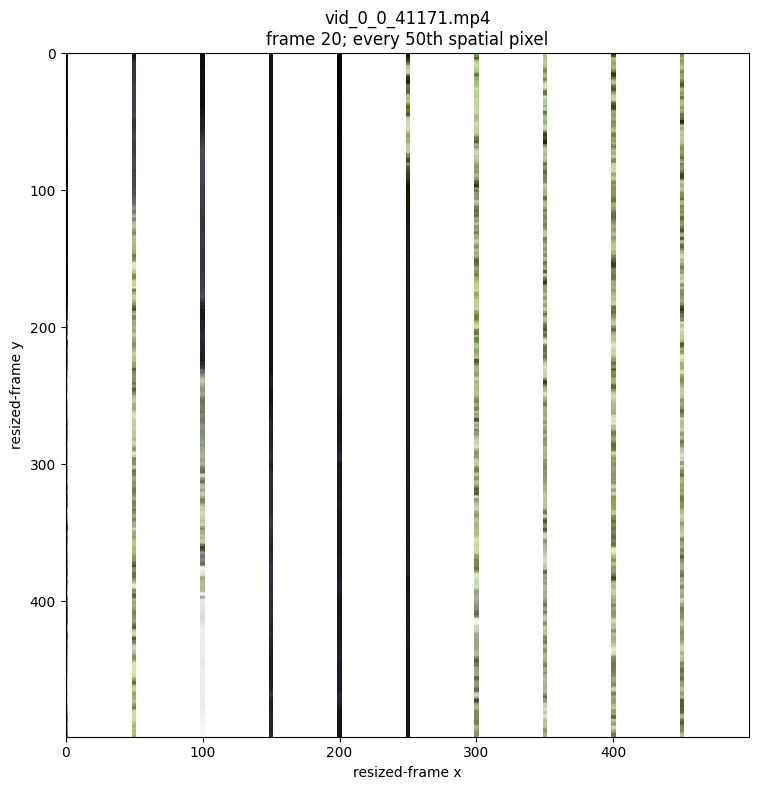

In [5]:
image_width = pixel_metadata["image_width"]
image_height = pixel_metadata["image_height"]
sample_indices = pixel_sample_indices(
    image_width,
    image_height,
    pixel_metadata["pixel_step"],
)
sample_rows, sample_columns = np.divmod(sample_indices, image_width)

expected_features = 3 * len(sample_indices)
if pixel_features.shape[0] != expected_features:
    raise ValueError(
        f"Expected {expected_features} RGB features from metadata, "
        f"got {pixel_features.shape[0]}."
    )
# end if feature count
if not 0 <= cfg.example_movie_index < len(pixel_movie_names):
    raise IndexError("example_movie_index is outside the movie axis.")
# end if movie index

example_frame = min(
    cfg.example_frame_index,
    pixel_features.shape[1] - 1,
)
example_vector = pixel_features[
    :, example_frame, cfg.example_movie_index
]
example_rgb = example_vector.reshape(-1, 3)

fig, ax = plt.subplots(figsize=(8, 8))
ax.scatter(
    sample_columns,
    sample_rows,
    c=example_rgb.astype(np.float32) / 255,
    s=10,
    marker="s",
    linewidths=0,
)
ax.set(
    title=(
        f"{pixel_movie_names[cfg.example_movie_index]}\n"
        f"frame {example_frame}; every "
        f"{pixel_metadata['pixel_step']}th spatial pixel"
    ),
    xlabel="resized-frame x",
    ylabel="resized-frame y",
    xlim=(0, image_width - 1),
    ylim=(image_height - 1, 0),
    aspect="equal",
)
fig.tight_layout()

print(f"Example RGB array [sampled locations,channels]: {example_rgb.shape}")
print("First five RGB triplets:")
print(example_rgb[:5])
print(
    f"RGB min/mean/max: {example_rgb.min()} / "
    f"{example_rgb.mean():.2f} / {example_rgb.max()}"
)

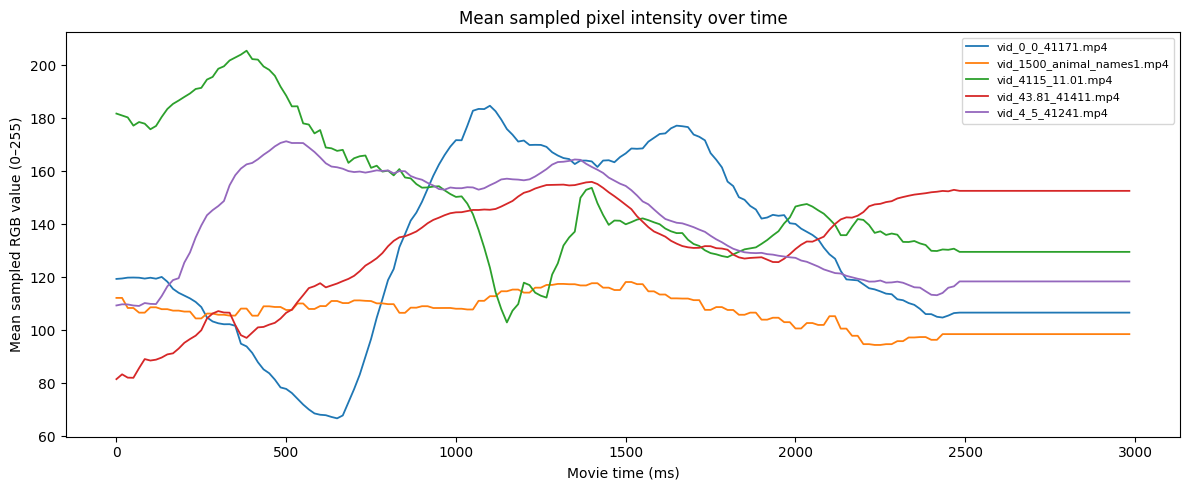

In [6]:
# Average all retained locations and channels to inspect gross luminance.
n_sampled_pixels = pixel_metadata["n_sampled_pixels"]
pixel_rgb_grid = pixel_features.reshape(
    n_sampled_pixels,
    3,
    pixel_features.shape[1],
    pixel_features.shape[2],
)
mean_rgb_intensity = pixel_rgb_grid.mean(axis=(0, 1))
source_model_time_ms = (
    np.arange(mean_rgb_intensity.shape[0]) * 1000 / source_pixel_fs
)

fig, ax = plt.subplots(figsize=(12, 5))
for movie_index in range(min(5, mean_rgb_intensity.shape[1])):
    ax.plot(
        source_model_time_ms,
        mean_rgb_intensity[:, movie_index],
        label=pixel_movie_names[movie_index],
        linewidth=1.3,
    )
# end for movie_index
ax.set(
    xlabel="Movie time (ms)",
    ylabel="Mean sampled RGB value (0–255)",
    title="Mean sampled pixel intensity over time",
)
ax.legend(fontsize=8)
fig.tight_layout()

## 6. Compute movie pixel-value dRSA

An RDM is computed across movie identities at every neural and pixel timepoint.
Before correlating the RDM time series, this section reports:

- non-finite RDM entries, usually caused by a constant stimulus vector under a
  correlation/cosine distance;
- zero-variance RDM timepoints, for which correlation-based RSA is undefined.

These checks make the origin of any NaNs explicit. NaNs in the final dRSA are
not arbitrary numerical noise: correlation has no defined value when either
RDM vector has zero variance.

In [7]:
pixel_drsa = dRSA(
    signal_RDM_metric=cfg.signal_RDM_metric,
    model_RDM_metric=cfg.model_RDM_metric,
    RSA_metric=cfg.RSA_metric,
)
pixel_drsa.compute_RDM_timeseries(video_neural_ts, "signal")
pixel_drsa.compute_RDM_timeseries(pixel_ts, "model")

# Convert TimeSeries lists to arrays with shape RDM entries x time.
pixel_drsa.signal_RDM_timeseries.to_numpy()
pixel_drsa.model_RDM_timeseries.to_numpy()
signal_rdms = pixel_drsa.signal_RDM_timeseries.get_array()
model_rdms = pixel_drsa.model_RDM_timeseries.get_array()

signal_nonfinite_times = np.flatnonzero(
    ~np.isfinite(signal_rdms).all(axis=0)
)
model_nonfinite_times = np.flatnonzero(
    ~np.isfinite(model_rdms).all(axis=0)
)
signal_constant_times = np.flatnonzero(
    np.nanstd(signal_rdms, axis=0) == 0
)
model_constant_times = np.flatnonzero(
    np.nanstd(model_rdms, axis=0) == 0
)

print(f"Signal RDMs [entries,time]: {signal_rdms.shape}")
print(f"Pixel RDMs [entries,time]: {model_rdms.shape}")
print(
    "Signal RDM timepoints with non-finite entries: "
    f"{signal_nonfinite_times.tolist()}"
)
print(
    "Pixel RDM timepoints with non-finite entries: "
    f"{model_nonfinite_times.tolist()}"
)
print(
    "Signal zero-variance RDM timepoints: "
    f"{signal_constant_times.tolist()}"
)
print(
    "Pixel zero-variance RDM timepoints: "
    f"{model_constant_times.tolist()}"
)

pixel_drsa_matrix = pixel_drsa.compute_dRSA()
analysis_fs = video_neural_ts.get_fs()
neural_time_ms = (
    np.arange(pixel_drsa_matrix.shape[0]) * 1000 / analysis_fs
)
model_time_ms = (
    np.arange(pixel_drsa_matrix.shape[1]) * 1000 / analysis_fs
)

n_nan_drsa = int(np.isnan(pixel_drsa_matrix).sum())
print(f"dRSA [neural time,pixel time]: {pixel_drsa_matrix.shape}")
print(
    f"NaNs in dRSA: {n_nan_drsa} / {pixel_drsa_matrix.size}. "
    "Rows/columns associated with a constant or non-finite RDM are undefined."
)

Signal RDMs [entries,time]: (4950, 350)
Pixel RDMs [entries,time]: (4950, 300)
Signal RDM timepoints with non-finite entries: []
Pixel RDM timepoints with non-finite entries: []
Signal zero-variance RDM timepoints: []
Pixel zero-variance RDM timepoints: []
dRSA [neural time,pixel time]: (350, 300)
NaNs in dRSA: 0 / 105000. Rows/columns associated with a constant or non-finite RDM are undefined.


18:40:13 - The number of datapoints used to compute extreme offsets is < than 10


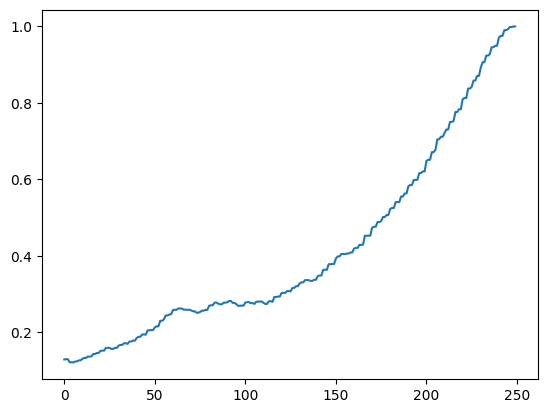

In [29]:
ac_mat, ac_line = pixel_drsa.model_RDM_timeseries.autocorr(max_lag=len(pixel_drsa.model_RDM_timeseries)-1)
# plt.imshow(ac_mat)
plt.plot(ac_mat[:250,250])
np.save("/Users/tizianocausin/Desktop/pix_ac_mat.npy", ac_mat)

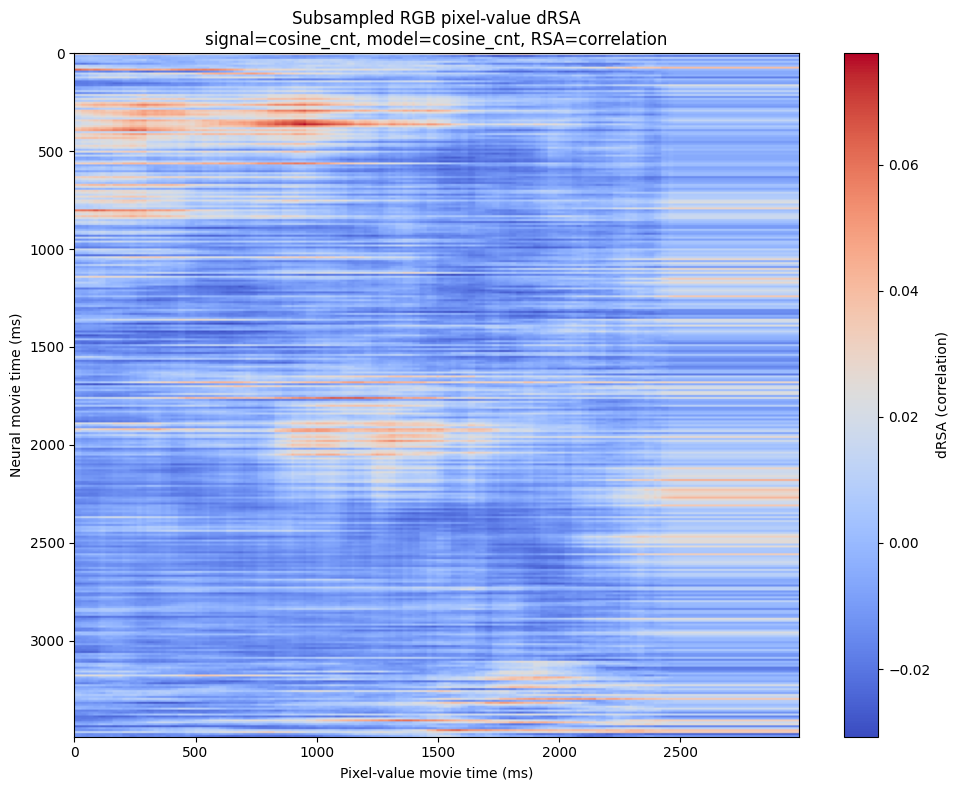

In [ ]:
fig, ax = plt.subplots(figsize=(10, 8))
image = ax.imshow(
    pixel_drsa_matrix,
    aspect="auto",
    origin="upper",
    cmap="coolwarm",
    extent=[
        model_time_ms[0],
        model_time_ms[-1],
        neural_time_ms[-1],
        neural_time_ms[0],
    ],
)
ax.set(
    xlabel="Pixel-value movie time (ms)",
    ylabel="Neural movie time (ms)",
    title=(
        "Subsampled RGB pixel-value dRSA\n"
        f"signal={cfg.signal_RDM_metric}, "
        f"model={cfg.model_RDM_metric}, RSA={cfg.RSA_metric}"
    ),
)
fig.colorbar(image, ax=ax, label=f"dRSA ({cfg.RSA_metric})")
fig.tight_layout()

## 7. Inspect example RDMs

After conversion, RDM time series use `(RDM entries, time)`. Selecting
`[:, time_index]` below is important; selecting a row would mix timepoints.

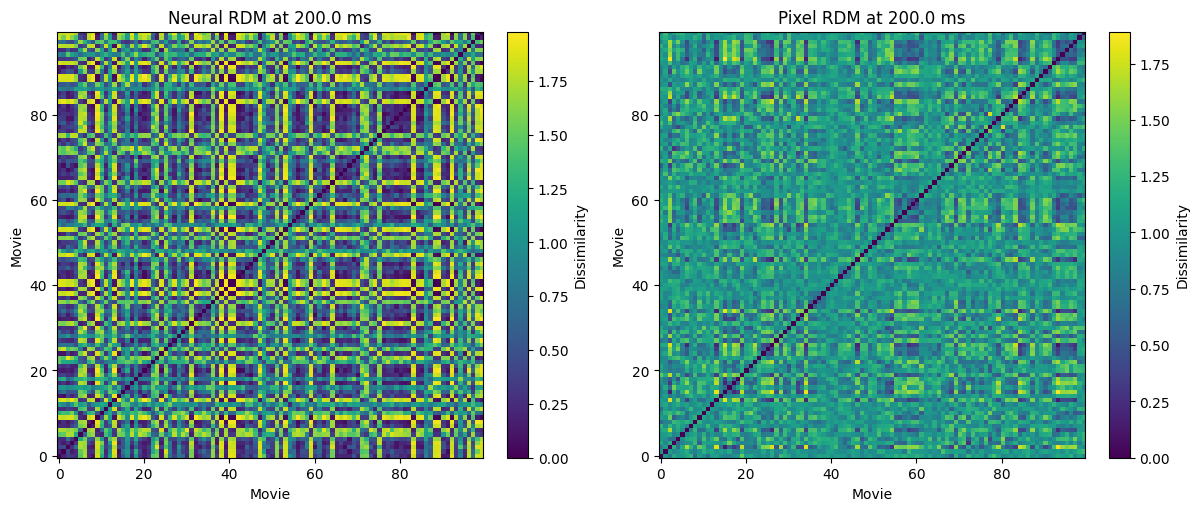

In [12]:
neural_rdm_index = min(example_frame, signal_rdms.shape[1] - 1)
model_rdm_index = min(example_frame, model_rdms.shape[1] - 1)
neural_rdm = squareform(signal_rdms[:, neural_rdm_index])
model_rdm = squareform(model_rdms[:, model_rdm_index])

fig, axes = plt.subplots(1, 2, figsize=(12, 5), constrained_layout=True)
for ax, rdm, title in (
    (
        axes[0],
        neural_rdm,
        f"Neural RDM at {neural_time_ms[neural_rdm_index]:.1f} ms",
    ),
    (
        axes[1],
        model_rdm,
        f"Pixel RDM at {model_time_ms[model_rdm_index]:.1f} ms",
    ),
):
    image = ax.imshow(rdm, cmap="viridis", origin="lower")
    ax.set(xlabel="Movie", ylabel="Movie", title=title)
    fig.colorbar(image, ax=ax, label="Dissimilarity")
# end for rdm

## 8. Physical-time-aligned dRSA curve

Pixel vectors and neural responses both start at movie time zero. The nearest
neural sample is selected for every available pixel time. NaNs are linearly
interpolated only in the smoothed display curve; the raw dRSA matrix is never
modified.

Aligned-curve peak: 0.0381 at 290.0 ms


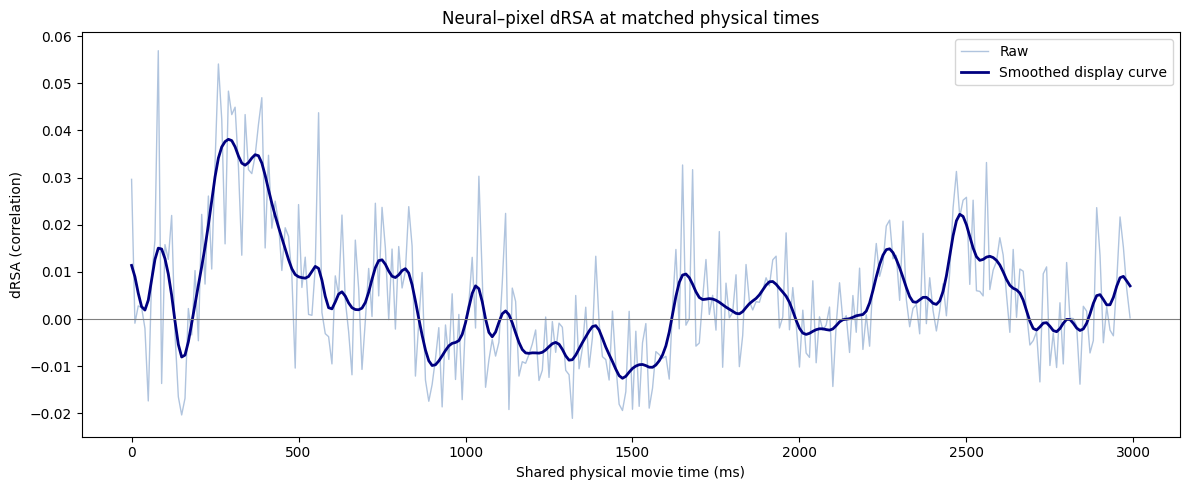

In [10]:
valid_model_indices = np.flatnonzero(
    model_time_ms <= neural_time_ms[-1]
)
matched_neural_indices = np.rint(
    model_time_ms[valid_model_indices] * analysis_fs / 1000
).astype(int)
matched_neural_indices = np.clip(
    matched_neural_indices,
    0,
    pixel_drsa_matrix.shape[0] - 1,
)
aligned_drsa = pixel_drsa_matrix[
    matched_neural_indices,
    valid_model_indices,
]

# Interpolate isolated display-curve NaNs before Gaussian smoothing. Endpoint
# NaNs use the nearest finite value. The raw aligned_drsa remains unchanged.
aligned_for_smoothing = aligned_drsa.copy()
finite_aligned = np.isfinite(aligned_for_smoothing)
if finite_aligned.any():
    aligned_for_smoothing[~finite_aligned] = np.interp(
        np.flatnonzero(~finite_aligned),
        np.flatnonzero(finite_aligned),
        aligned_for_smoothing[finite_aligned],
    )
    aligned_drsa_smoothed = gaussian_filter1d(
        aligned_for_smoothing,
        sigma=cfg.aligned_curve_smoothing_sigma,
    )
else:
    aligned_drsa_smoothed = np.full_like(aligned_for_smoothing, np.nan)
# end if finite_aligned

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(
    model_time_ms[valid_model_indices],
    aligned_drsa,
    color="lightsteelblue",
    linewidth=1,
    label="Raw",
)
ax.plot(
    model_time_ms[valid_model_indices],
    aligned_drsa_smoothed,
    color="navy",
    linewidth=2,
    label="Smoothed display curve",
)
ax.axhline(0, color="grey", linewidth=0.8)
ax.set(
    xlabel="Shared physical movie time (ms)",
    ylabel=f"dRSA ({cfg.RSA_metric})",
    title="Neural–pixel dRSA at matched physical times",
)
ax.legend()
fig.tight_layout()

if np.isfinite(aligned_drsa_smoothed).any():
    peak_index = int(np.nanargmax(aligned_drsa_smoothed))
    print(
        f"Aligned-curve peak: {aligned_drsa_smoothed[peak_index]:.4f} "
        f"at {model_time_ms[valid_model_indices][peak_index]:.1f} ms"
    )
else:
    print("Aligned curve has no finite values; inspect the RDM diagnostics.")
# end if finite smoothed curve

## 9. Lag analysis

Physical lag is `neural time - pixel time`. Because both time axes start at
zero after resampling, sample lag converts directly to milliseconds.

Lag peak: 0.0047 at 0.0 ms


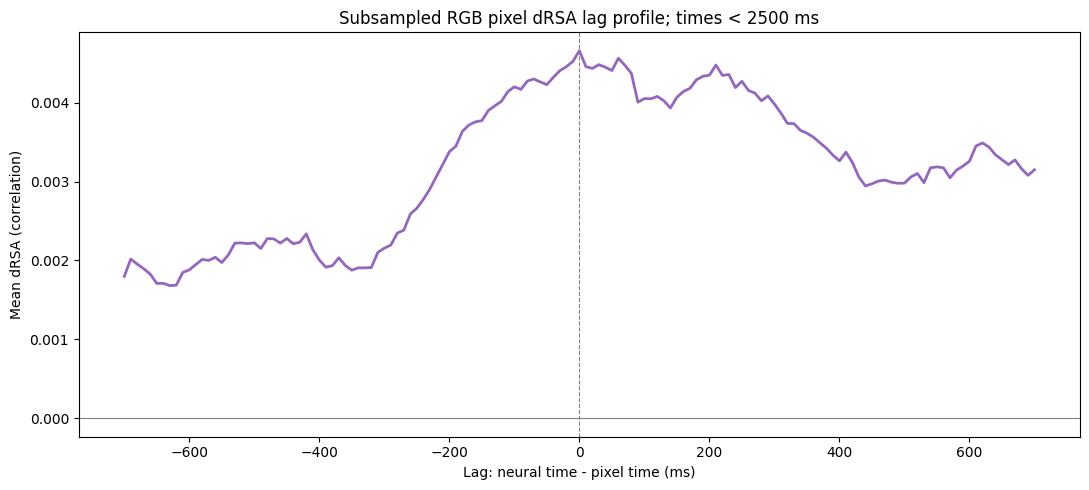

In [11]:
neural_analysis_indices = np.flatnonzero(
    neural_time_ms < cfg.lag_analysis_end_ms
)
model_analysis_indices = np.flatnonzero(
    model_time_ms < cfg.lag_analysis_end_ms
)
max_lag_samples = min(
    int(round(cfg.max_lag_ms * analysis_fs / 1000)),
    len(neural_analysis_indices) - 1,
    len(model_analysis_indices) - 1,
)
if max_lag_samples < 1:
    raise ValueError("The lag-analysis window is too short.")
# end if max_lag_samples

pixel_lagplot = get_lagplot_subset(
    pixel_drsa_matrix,
    neural_idx=neural_analysis_indices,
    model_idx=model_analysis_indices,
    max_lag=max_lag_samples,
)
sample_lags = np.arange(-max_lag_samples, max_lag_samples + 1)
physical_lag_ms = sample_lags * 1000 / analysis_fs

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(physical_lag_ms, pixel_lagplot, color="tab:purple", linewidth=2)
ax.axhline(0, color="grey", linewidth=0.8)
ax.axvline(0, color="grey", linewidth=0.8, linestyle="--")
ax.set(
    xlabel="Lag: neural time - pixel time (ms)",
    ylabel=f"Mean dRSA ({cfg.RSA_metric})",
    title=(
        "Subsampled RGB pixel dRSA lag profile; "
        f"times < {cfg.lag_analysis_end_ms:g} ms"
    ),
)
fig.tight_layout()

if np.isfinite(pixel_lagplot).any():
    peak_lag_index = int(np.nanargmax(pixel_lagplot))
    print(
        f"Lag peak: {pixel_lagplot[peak_lag_index]:.4f} "
        f"at {physical_lag_ms[peak_lag_index]:.1f} ms"
    )
else:
    print("Lag profile has no finite values; inspect the RDM diagnostics.")
# end if finite lag profile

## Interpretation

- Positive lag means neural representational geometry is later than pixel
  geometry; negative lag means it is earlier.
- Every 50th **spatial** pixel is retained, with all three RGB channels.
- The subsampling pattern is row-major and fixed across every frame and movie.
- With `frame_stride > 1`, the HDF5 metadata and effective sampling rate change
  accordingly.
- Raw pixel RDMs are a useful low-level baseline, but they remain sensitive to
  luminance, contrast, background, spatial alignment, and camera motion.
- Correlation-based dRSA is undefined for a zero-variance RDM. The diagnostic
  cell prints the precise neural or model timepoints that cause those NaNs.